# Backbone Ablation

This notebook visualizes backbone-size ablations from the Excel result files in `results/`.

It covers:
- V-JEPA 2.1 backbone sweep: ViT-B/16, ViT-L/16, ViT-G/16, ViT-Gigantic/16
- VideoMAE-v2 backbone sweep: ViT-B/16, ViT-L/16, ViT-G/16
- LTX-Video comparison: LTX-2B and LTX-13B across noise levels and transformer blocks


# Backbone Ablation Results

This notebook reads the Excel result databases in `results/` and focuses on backbone ablations: V-JEPA 2.1 and VideoMAE-v2 backbone-size sweeps, plus LTX-2B versus LTX-13B denoising/block sweeps. Best rows are selected by validation primary metric and reported on test primary metric.

**Loaded ablation coverage**

,Dataset,model_label,backbone,experiment,Probe,n_rows,val_min,val_max,test_min,test_max
2,IntPhys2,LTX-Video,LTX-13B,ltx,Attentive,4,41.18,56.86,41.18,43.14
0,IntPhys2,LTX-Video,LTX-13B,ltx,Linear,40,0.00,45.10,0.00,49.02
1,IntPhys2,LTX-Video,LTX-13B,ltx,MLP,40,0.00,43.14,0.00,47.06
5,IntPhys2,LTX-Video,LTX-2B,ltx,Attentive,4,17.65,21.57,9.80,35.29
3,IntPhys2,LTX-Video,LTX-2B,ltx,Linear,40,0.00,29.41,0.00,27.45
4,IntPhys2,LTX-Video,LTX-2B,ltx,MLP,40,0.00,29.41,0.00,27.45
8,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,Attentive,4,13.73,64.71,11.76,58.82
6,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,Linear,4,23.53,45.10,11.76,39.22
7,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,MLP,4,19.61,45.10,25.49,50.98
11,IntPhys2,V-JEPA 2.1,ViT-G/16,backbone_sweep,Attentive,4,19.61,64.71,19.61,60.78


## V-JEPA 2.1 and VideoMAE-v2 Backbone Sweep

**Best layer per backbone, selected by validation primary metric**

,Dataset,Model,backbone,experiment,Probe,layer_label,best_validation_score,primary_score,test_accuracy
2,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,Attentive,12,64.71,56.86,74.51
0,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,Linear,9,45.10,15.69,51.96
1,IntPhys2,V-JEPA 2.1,ViT-B/16,backbone_sweep,MLP,12,45.10,50.98,63.24
5,IntPhys2,V-JEPA 2.1,ViT-G/16,backbone_sweep,Attentive,40,64.71,60.78,74.51
3,IntPhys2,V-JEPA 2.1,ViT-G/16,backbone_sweep,Linear,30,37.25,33.33,52.45
4,IntPhys2,V-JEPA 2.1,ViT-G/16,backbone_sweep,MLP,30,39.22,35.29,57.35
8,IntPhys2,V-JEPA 2.1,ViT-Gigantic/16,main,Attentive,48,60.78,60.78,72.55
6,IntPhys2,V-JEPA 2.1,ViT-Gigantic/16,main,Linear,Layer 0.75,33.33,23.53,52.94
7,IntPhys2,V-JEPA 2.1,ViT-Gigantic/16,main,MLP,Layer 0.75,45.10,39.22,57.35
11,IntPhys2,V-JEPA 2.1,ViT-L/16,same_L,Attentive,24,66.67,58.82,72.55


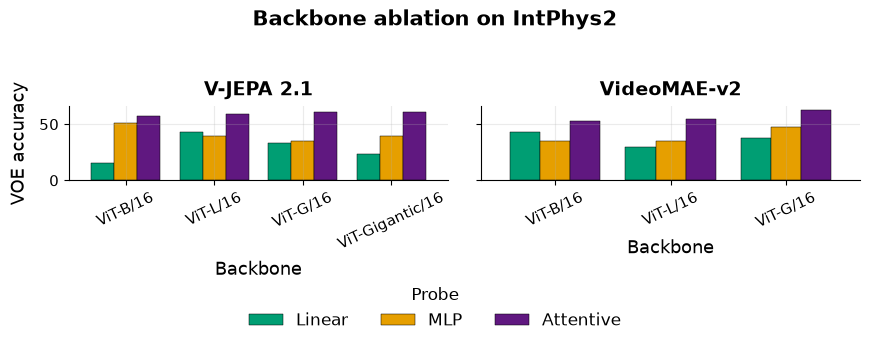

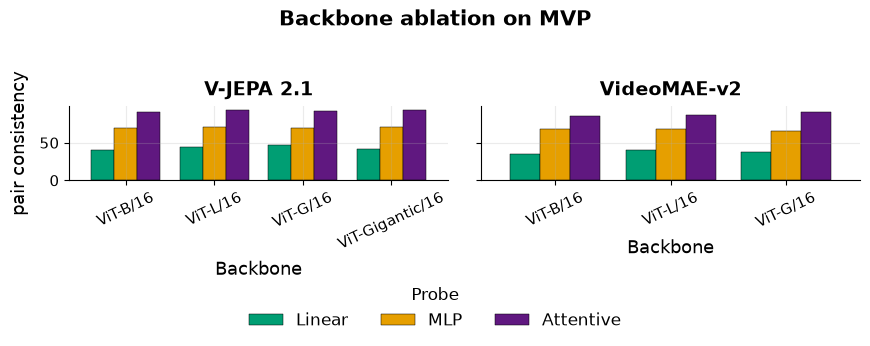

### Depth Profiles: Linear

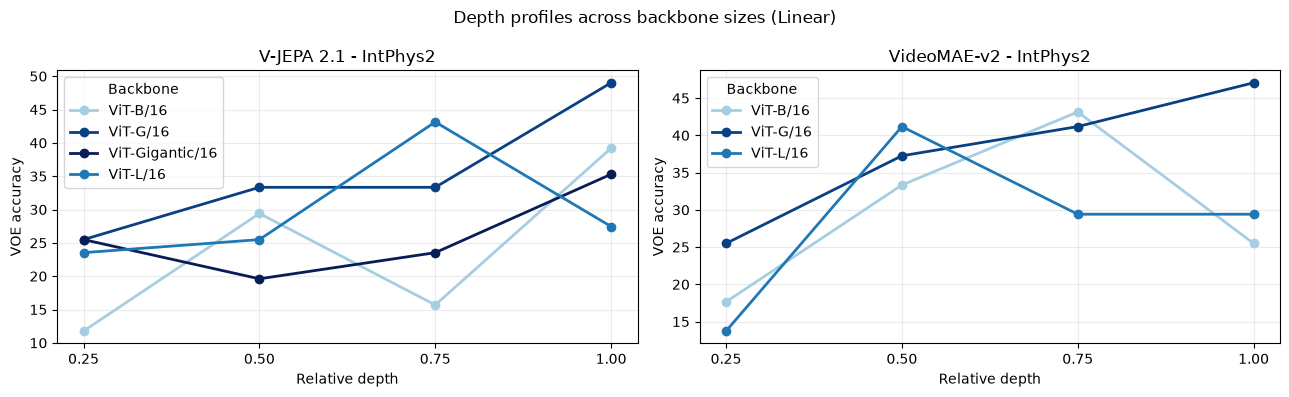

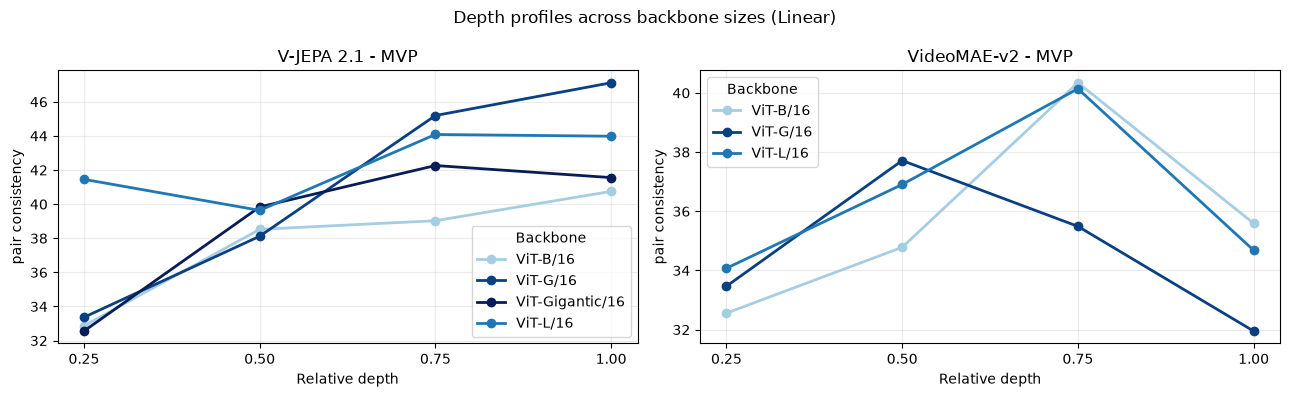

### Depth Profiles: MLP

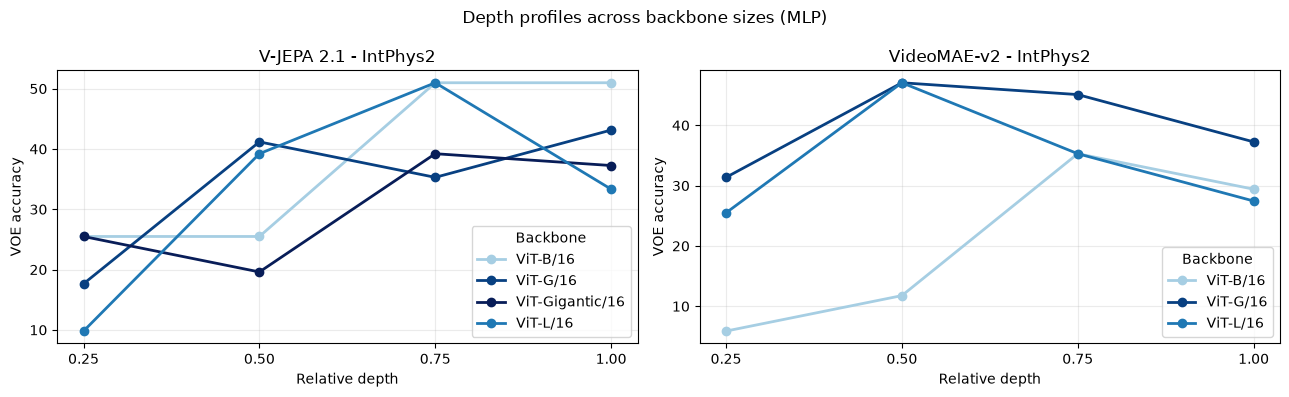

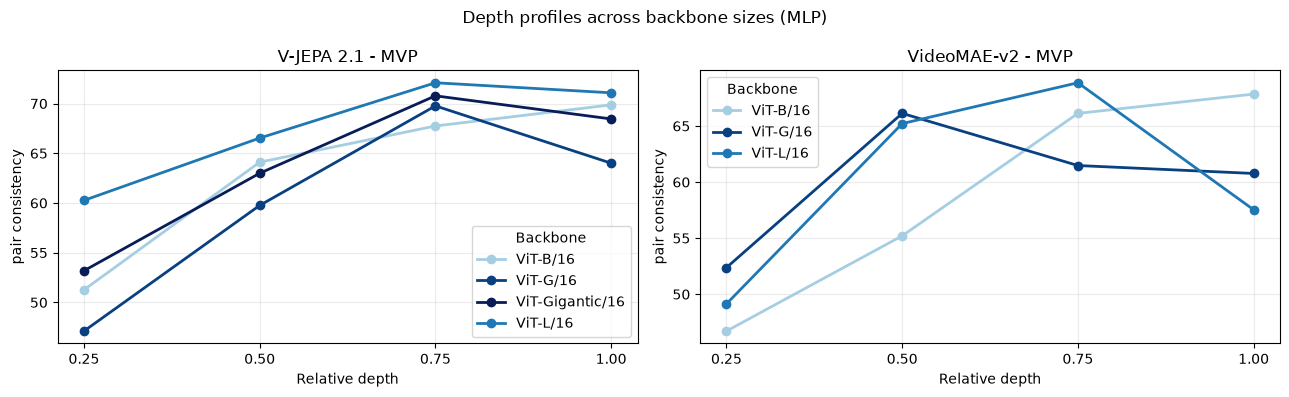

### Depth Profiles: Attentive

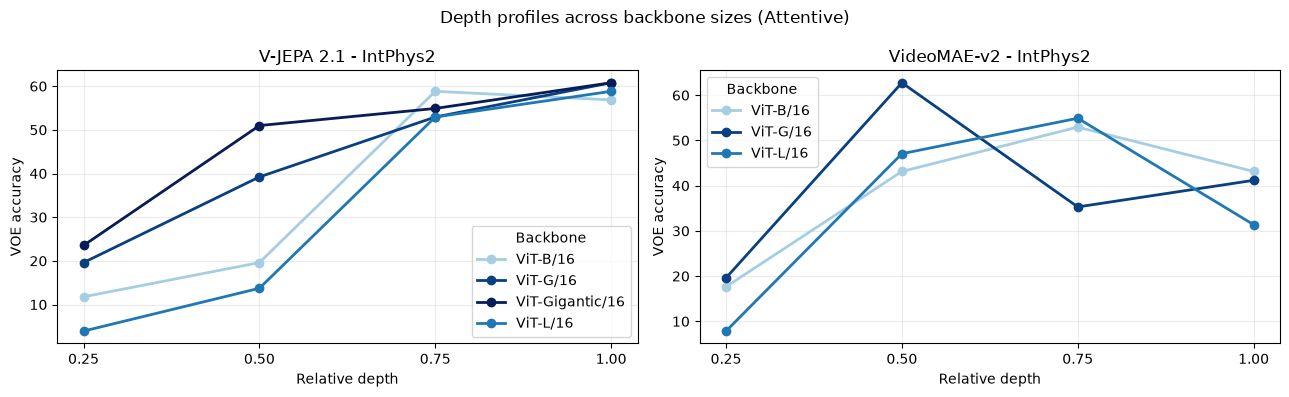

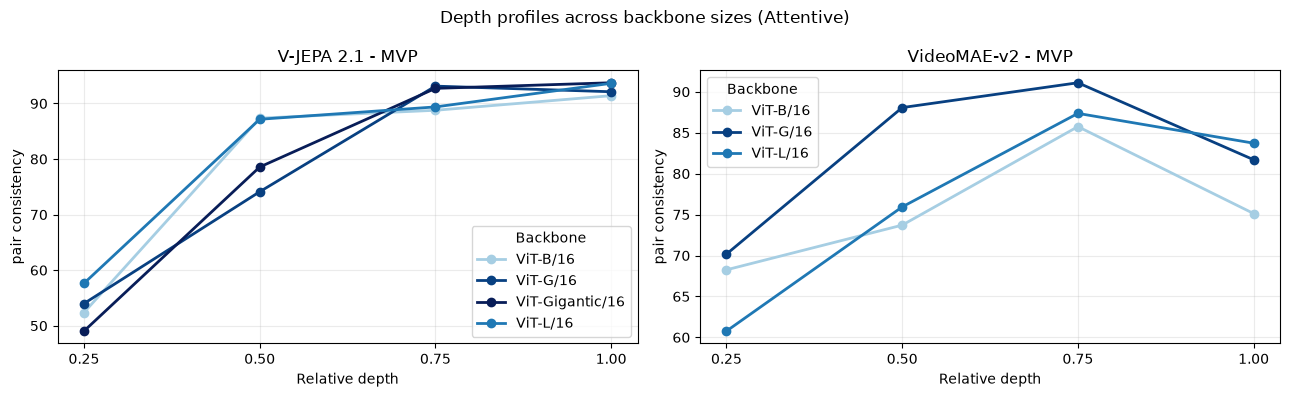

### Backbone x Depth Heatmaps: Linear

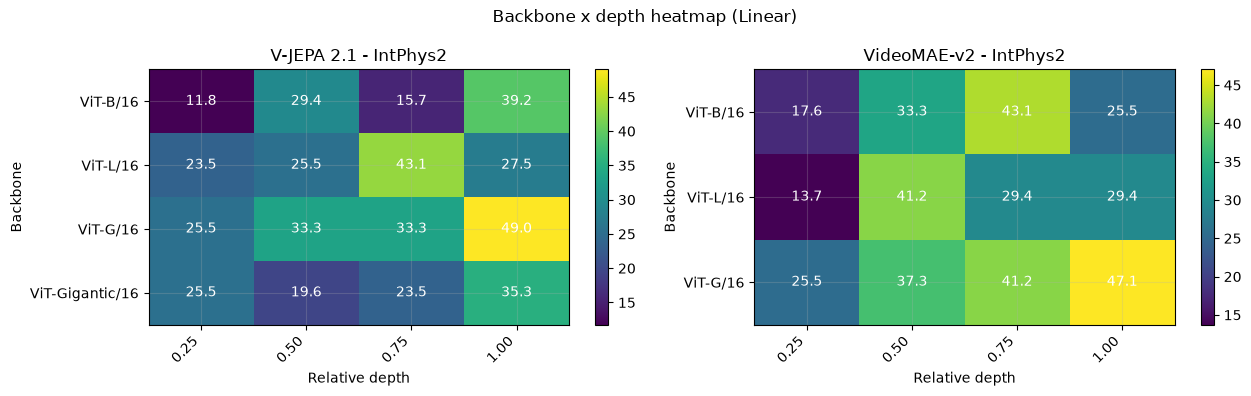

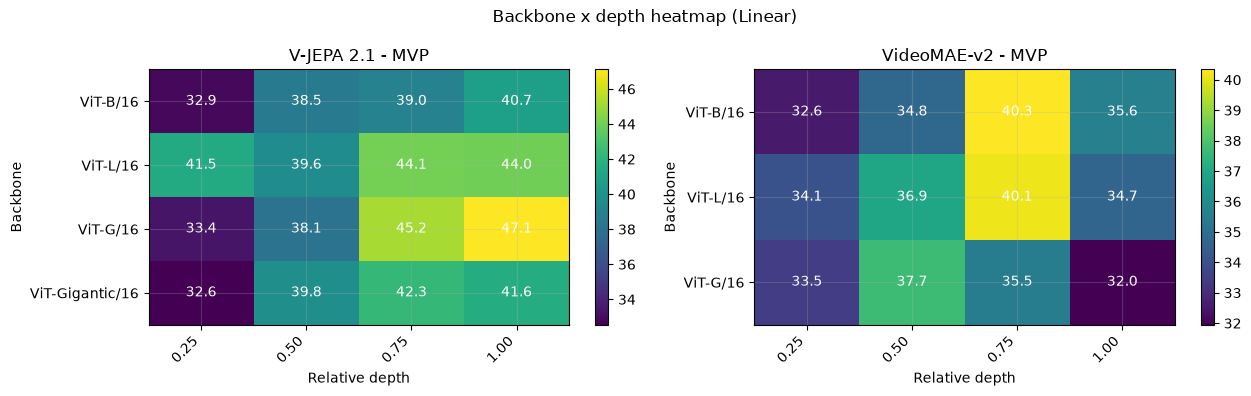

### Backbone x Depth Heatmaps: MLP

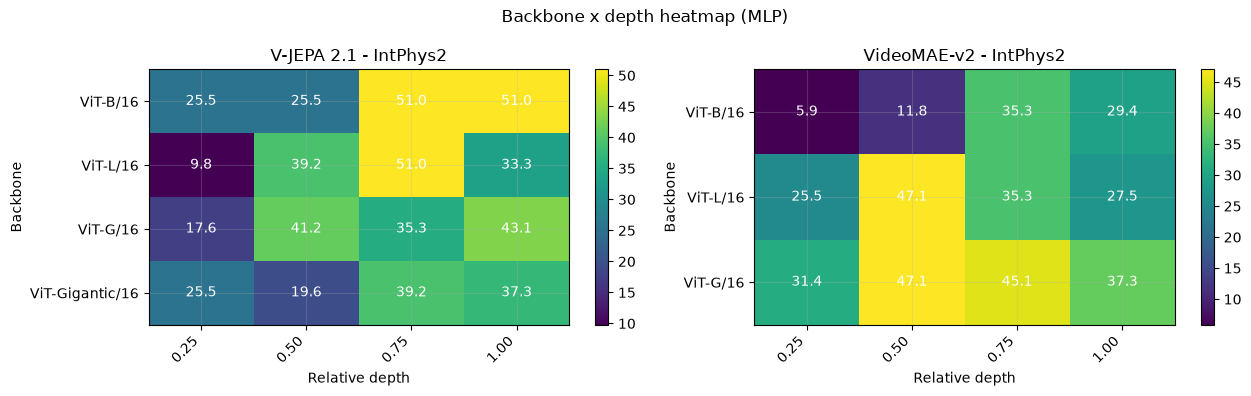

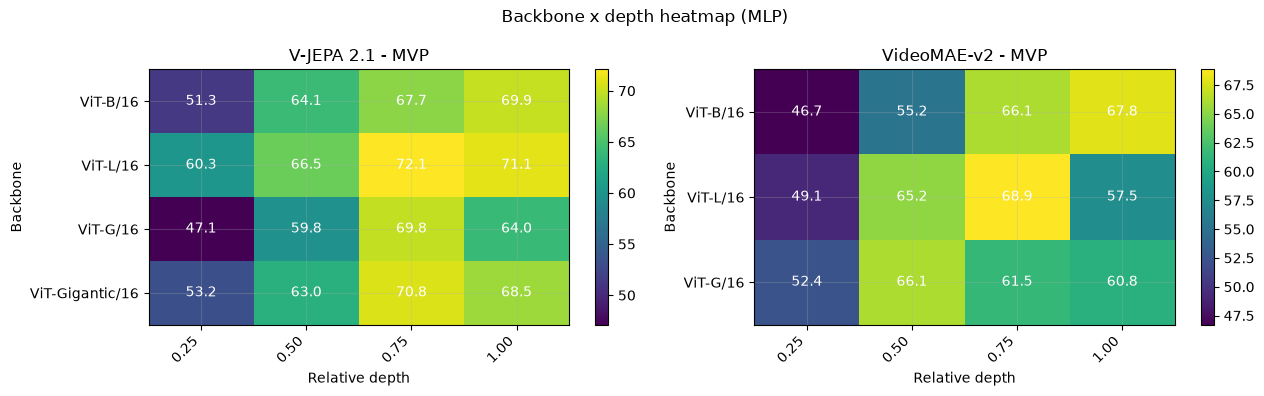

### Backbone x Depth Heatmaps: Attentive

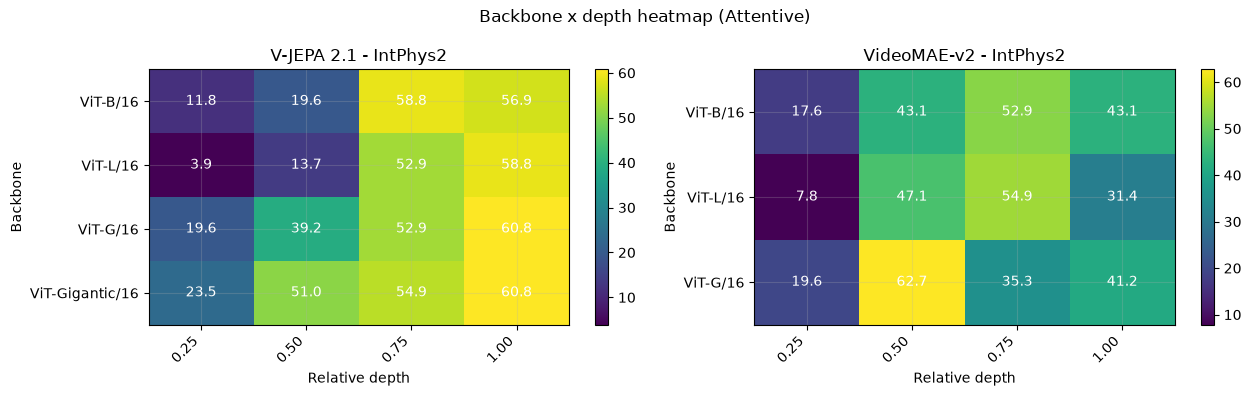

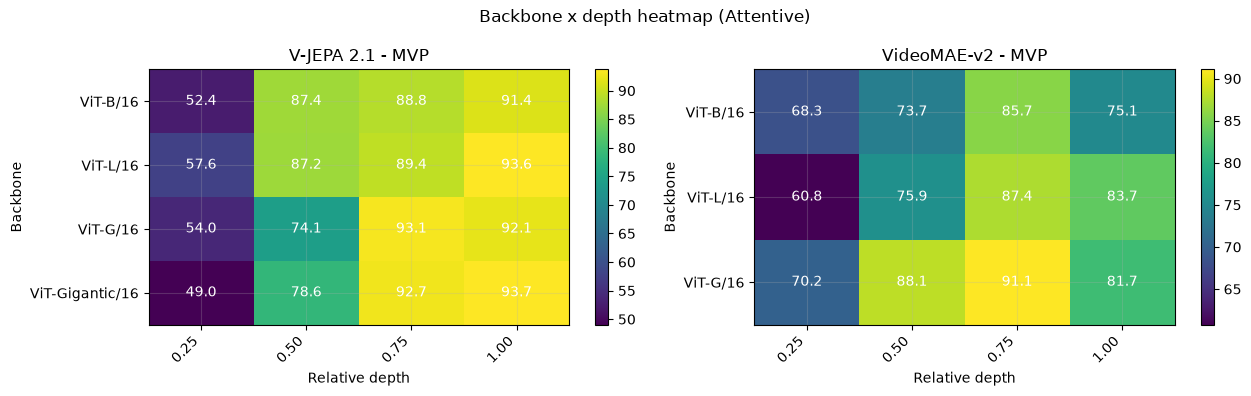

## LTX-Video 2B vs 13B

**Best LTX stage per backbone/probe, selected by validation primary metric**

,Dataset,backbone,Probe,layer_label,ltx_noise_level,ltx_block,best_validation_score,primary_score,test_accuracy
2,IntPhys2,LTX-13B,Attentive,39,,,56.86,43.14,65.20
0,IntPhys2,LTX-13B,Linear,noise_0.2_block_24,0.20,24.00,45.10,47.06,62.25
1,IntPhys2,LTX-13B,MLP,noise_0.2_block_24,0.20,24.00,43.14,47.06,61.76
5,IntPhys2,LTX-2B,Attentive,39,,,21.57,25.49,51.96
3,IntPhys2,LTX-2B,Linear,noise_0.3_block_14,0.30,14.00,29.41,27.45,52.94
4,IntPhys2,LTX-2B,MLP,noise_0.4_block_14,0.40,14.00,29.41,19.61,50.98
8,MVP,LTX-13B,Attentive,noise_0.2_block_24,0.20,24.00,86.96,83.01,90.75
6,MVP,LTX-13B,Linear,noise_0.6_block_24,0.60,24.00,55.11,49.95,71.33
7,MVP,LTX-13B,MLP,noise_0.5_block_24,0.50,24.00,70.98,66.84,81.60
9,MVP,LTX-2B,Linear,noise_0.1_block_7,0.10,7.00,29.83,28.31,58.54


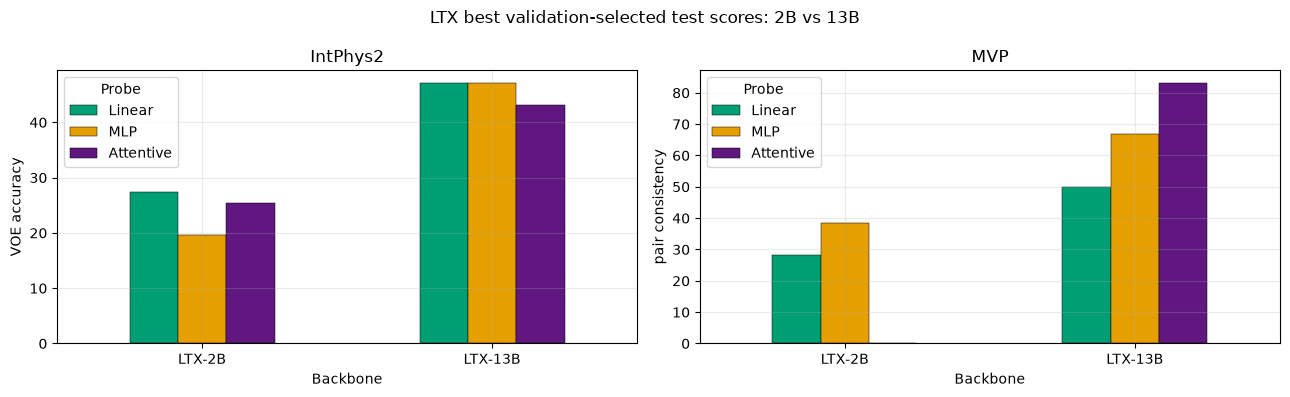

### LTX Noise x Block: Linear

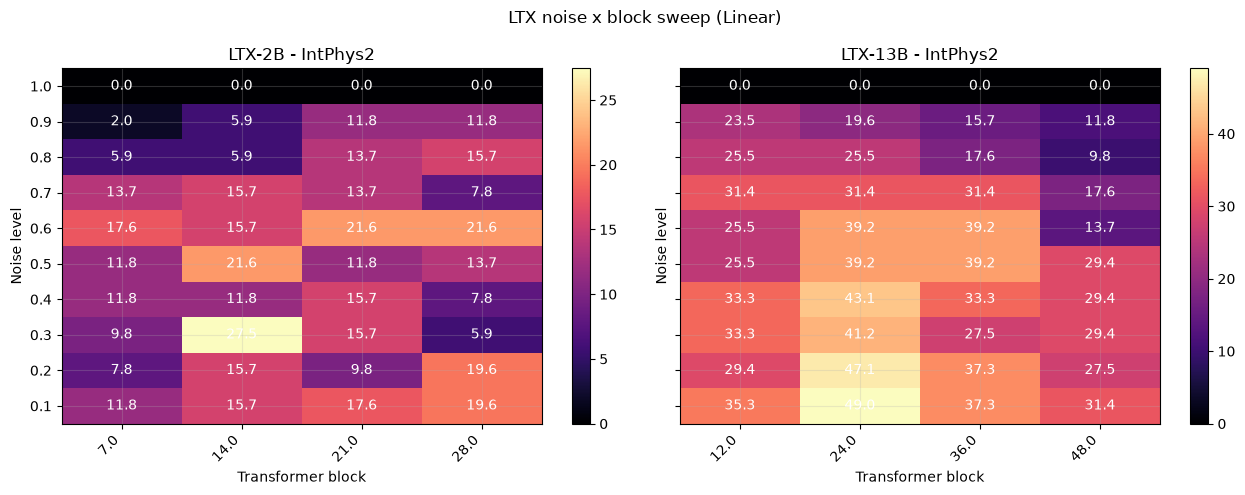

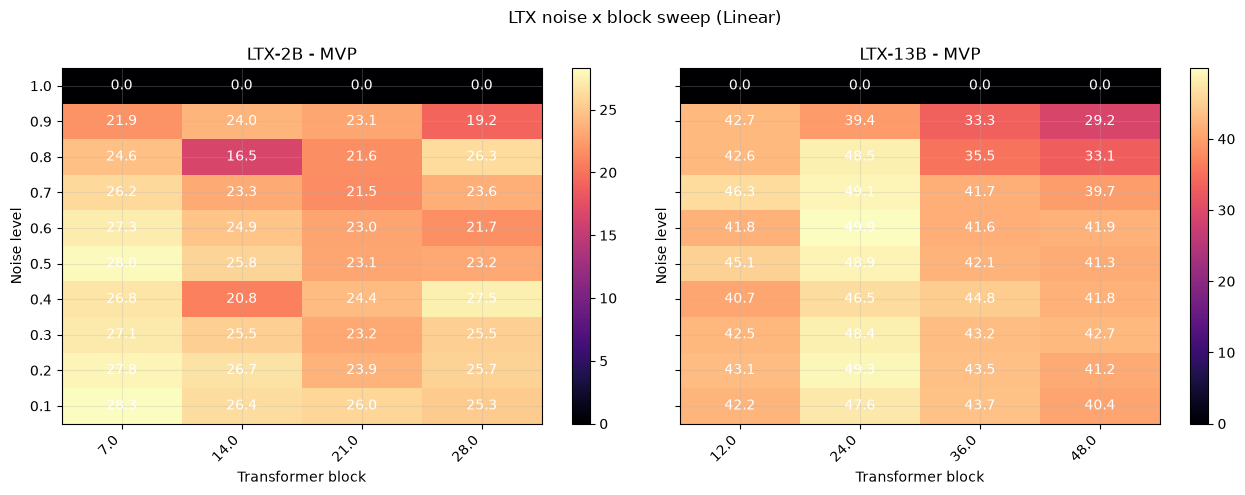

### LTX Noise x Block: MLP

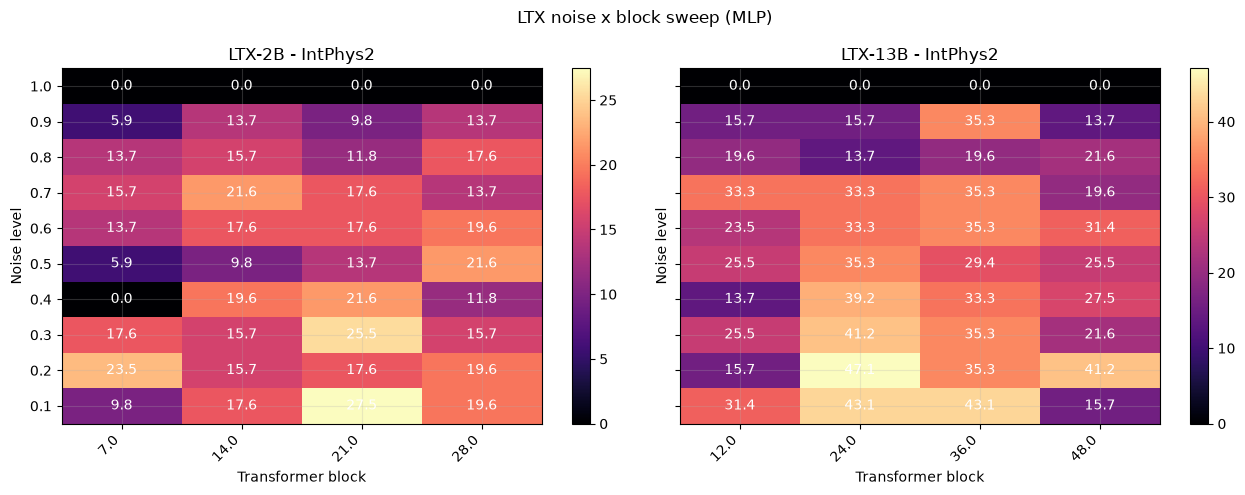

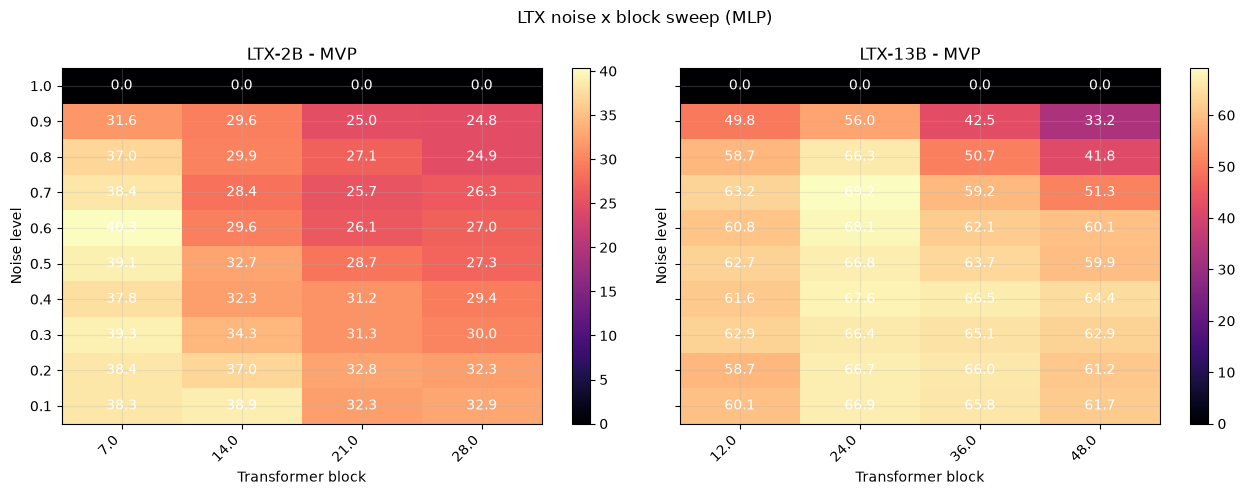

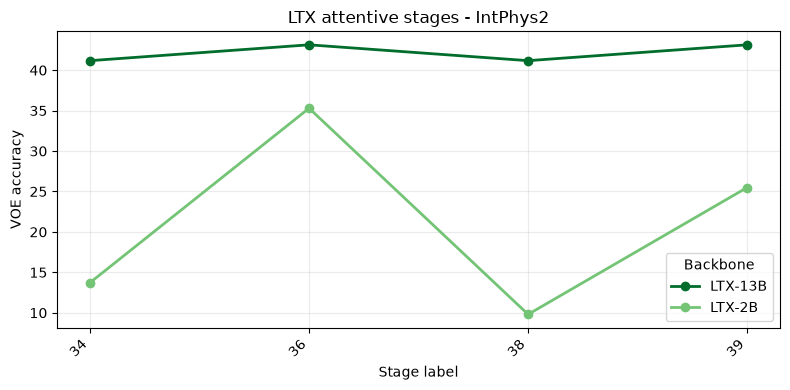

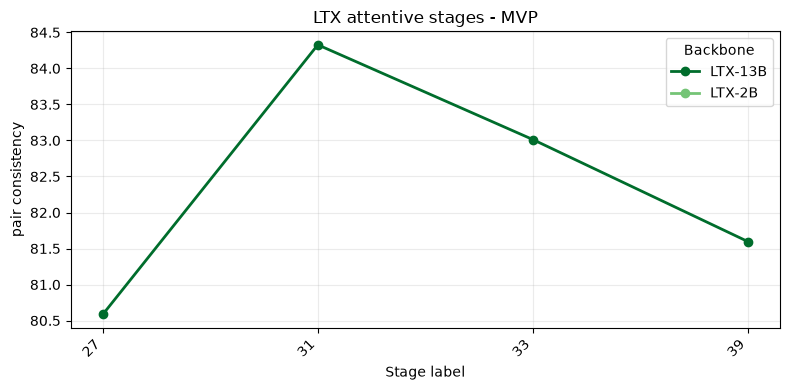

In [2]:
from pathlib import Path
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/probe4physics_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/probe4physics_cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})
plt.rcParams['figure.max_open_warning'] = 0

def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'run.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing results/ and run.py')

REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import importlib
import plot_colors
importlib.reload(plot_colors)
from plot_colors import BACKBONE_COLORS, FAMILY_COLORS, MODEL_COLORS, PROBE_COLORS, PROBE_LABEL_COLORS

RESULTS_DIR = REPO_ROOT / 'results'
MVP_XLSX = RESULTS_DIR / 'mvp_primary_db.xlsx'
INTPHYS_XLSX = RESULTS_DIR / 'intphys_primary_db.xlsx'

DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_LABEL = {'mvp': 'pair consistency', 'intphys2': 'VOE accuracy'}
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'Linear', 'mlp': 'MLP', 'temporal_attn': 'Attentive'}
ABLATION_MODELS = ['jepa_v2_1', 'videomae_v2']
MODEL_LABEL = {'jepa_v2_1': 'V-JEPA 2.1', 'videomae_v2': 'VideoMAE-v2', 'ltx_video': 'LTX-Video'}
MODEL_FAMILY = {'jepa_v2_1': 'V-JEPA', 'videomae_v2': 'VideoMAE', 'ltx_video': 'LTX-Video'}
SHEET_TO_MODEL_KEY = {
    'V-JEPA': 'jepa_v1',
    'V-JEPA 2': 'jepa_v2',
    'V-JEPA 2.1': 'jepa_v2_1',
    'VideoMAE': 'videomae',
    'VideoMAE-v2': 'videomae_v2',
    'LTX-Video': 'ltx_video',
}
BACKBONE_ORDER = {
    'ViT-B/16': 0,
    'ViT-L/16': 1,
    'ViT-G/16': 2,
    'ViT-Gigantic/16': 3,
    'LTX-2B': 0,
    'LTX-13B': 1,
}
PAPER_BACKBONE = {
    'jepa_v2_1': 'ViT-Gigantic/16',
    'videomae_v2': 'ViT-G/16',
    'ltx_video': 'LTX-13B',
}

for required in [MVP_XLSX, INTPHYS_XLSX]:
    if not required.exists():
        raise FileNotFoundError(f'Missing required workbook: {required}')

def canonical_probe(value):
    text = str(value).strip().lower()
    if text == 'linear':
        return 'linear'
    if text == 'mlp':
        return 'mlp'
    if text in {'attentive', 'temporalattn', 'temporal_attn', 'temporal attentive'}:
        return 'temporal_attn'
    return text or None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def parse_primary_workbook(path, dataset):
    frames = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        raw = xl.parse(sheet)
        cols = list(raw.columns)
        starts = [idx for idx, col in enumerate(cols) if not str(col).startswith('Unnamed') and 'primary metric' in str(col).lower()]
        for start in starts:
            end = min(start + 11, len(cols))
            title = str(cols[start])
            backbone = title.split(' - primary metric:', 1)[0].strip()
            block = raw.iloc[:, start:end].copy()
            headers = [str(item).strip() for item in block.iloc[0].tolist()]
            block = block.iloc[1:].copy()
            block.columns = headers
            block = block.dropna(how='all')
            if 'Experiment' not in block.columns:
                continue
            block = block[block['Experiment'].notna()].copy()
            if block.empty:
                continue
            block['dataset'] = dataset
            block['workbook'] = path.name
            block['sheet'] = sheet
            block['model_key'] = SHEET_TO_MODEL_KEY.get(sheet, sheet)
            block['backbone'] = backbone
            frames.append(block)
    return pd.concat(frames, ignore_index=True, sort=False)

def add_relative_depth(df):
    df = df.copy()
    df['relative_depth'] = np.nan
    # Non-LTX backbones have four depth slots. Prefer explicit layer labels when present;
    # otherwise use sorted layer rank inside each model/backbone/probe/dataset group.
    for _, group in df[~df['model_key'].eq('ltx_video')].groupby(['dataset', 'model_key', 'backbone', 'probe'], dropna=False):
        group = group.sort_values(['layer_numeric', 'layer_label'])
        count = len(group)
        for rank, idx in enumerate(group.index, start=1):
            label = str(df.loc[idx, 'layer_label']).lower()
            if 'final' in label:
                rel = 1.0
            elif '0.25' in label:
                rel = 0.25
            elif '0.5' in label or '0.50' in label:
                rel = 0.50
            elif '0.75' in label:
                rel = 0.75
            else:
                rel = rank / count if count else np.nan
            df.loc[idx, 'relative_depth'] = rel
    df['relative_depth_label'] = df['relative_depth'].map(lambda value: pd.NA if pd.isna(value) else f'{value:.2f}')
    return df

def load_results():
    raw = pd.concat([
        parse_primary_workbook(INTPHYS_XLSX, 'intphys2'),
        parse_primary_workbook(MVP_XLSX, 'mvp'),
    ], ignore_index=True, sort=False)
    rename = {
        'Experiment': 'experiment',
        'Probe': 'probe_raw',
        'Layer': 'layer',
        'Layer Label': 'layer_label',
        'Selected LR': 'selected_lr',
        'Train Accuracy': 'train_accuracy',
        'Val Accuracy': 'val_accuracy',
        'Test Accuracy': 'test_accuracy',
        'Train Primary Metric': 'train_primary',
        'Val Primary Metric': 'val_primary',
        'Test Primary Metric': 'test_primary',
    }
    df = raw.rename(columns=rename).copy()
    df['probe'] = df['probe_raw'].map(canonical_probe)
    for col in ['layer', 'selected_lr', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'train_primary', 'val_primary', 'test_primary']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['layer_numeric'] = pd.to_numeric(df['layer'], errors='coerce')
    df['layer_label'] = df['layer_label'].astype('string')
    df['model_label'] = df['model_key'].map(MODEL_LABEL).fillna(df['sheet'])
    df['backbone_order'] = df['backbone'].map(BACKBONE_ORDER).fillna(999).astype(int)
    df['is_paper_backbone'] = df['backbone'].eq(df['model_key'].map(PAPER_BACKBONE))
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df = add_relative_depth(df)
    return df

def select_best_by_val(df, group_cols):
    candidates = df.dropna(subset=['val_primary']).copy()
    if candidates.empty:
        return candidates
    ordered = candidates.sort_values(group_cols + ['val_primary', 'test_primary'])
    best = ordered.groupby(group_cols, group_keys=False).tail(1).copy()
    best['primary_score'] = best['test_primary']
    best['best_validation_score'] = best['val_primary']
    return best.reset_index(drop=True)

def show_table(df, title, precision=2):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=precision, na_rep=''))

def draw_heatmap(pivot, title, ax, cmap='viridis'):
    if pivot.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_axis_off()
        ax.set_title(title)
        return
    if sns is not None:
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True)
    else:
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, aspect='auto', cmap=cmap)
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', color='white')
    ax.set_title(title)

results = load_results()
backbone_sweep = results[results['model_key'].isin(ABLATION_MODELS)].copy()
ltx = results[results['model_key'].eq('ltx_video')].copy()

# Best per dataset/model/backbone/probe using validation metric, across the available rows for that backbone.
backbone_best = select_best_by_val(backbone_sweep, ['dataset', 'model_key', 'backbone', 'probe'])
ltx_best = select_best_by_val(ltx, ['dataset', 'backbone', 'probe'])

display(Markdown('# Backbone Ablation Results'))
display(Markdown(
    'This notebook reads the Excel result databases in `results/` and focuses on backbone ablations: '
    'V-JEPA 2.1 and VideoMAE-v2 backbone-size sweeps, plus LTX-2B versus LTX-13B denoising/block sweeps. '
    'Best rows are selected by validation primary metric and reported on test primary metric.'
))

coverage = (
    pd.concat([backbone_sweep, ltx], ignore_index=True)
    .groupby(['dataset', 'model_label', 'backbone', 'experiment', 'probe'], as_index=False)
    .agg(n_rows=('test_primary', 'size'), val_min=('val_primary', 'min'), val_max=('val_primary', 'max'), test_min=('test_primary', 'min'), test_max=('test_primary', 'max'))
)
coverage['Dataset'] = coverage['dataset'].map(DATASET_LABEL)
coverage['Probe'] = coverage['probe'].map(PROBE_LABEL)
show_table(
    coverage[['Dataset', 'model_label', 'backbone', 'experiment', 'Probe', 'n_rows', 'val_min', 'val_max', 'test_min', 'test_max']]
    .sort_values(['Dataset', 'model_label', 'backbone', 'Probe']),
    'Loaded ablation coverage'
)

display(Markdown('## V-JEPA 2.1 and VideoMAE-v2 Backbone Sweep'))
summary = backbone_best.copy()
summary['Dataset'] = summary['dataset'].map(DATASET_LABEL)
summary['Model'] = summary['model_key'].map(MODEL_LABEL)
summary['Probe'] = summary['probe'].map(PROBE_LABEL)
show_table(
    summary[['Dataset', 'Model', 'backbone', 'experiment', 'Probe', 'layer_label', 'best_validation_score', 'primary_score', 'test_accuracy']]
    .sort_values(['Dataset', 'Model', 'backbone', 'Probe']),
    'Best layer per backbone, selected by validation primary metric'
)

def plot_backbone_best_bars(best):
    for dataset in DATASET_ORDER:
        fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), sharey=True)
        legend_handles = None
        legend_labels = None
        for ax, model_key in zip(axes, ABLATION_MODELS):
            sub = best[(best['dataset'].eq(dataset)) & (best['model_key'].eq(model_key))].copy()
            backbone_order = sorted(sub['backbone'].unique(), key=lambda b: BACKBONE_ORDER.get(b, 999))
            sub['Backbone'] = pd.Categorical(sub['backbone'], categories=backbone_order, ordered=True)
            sub['Probe'] = sub['probe'].map(PROBE_LABEL)
            pivot = (
                sub.pivot_table(index='Backbone', columns='Probe', values='primary_score', aggfunc='max')
                .reindex(index=backbone_order, columns=[PROBE_LABEL[p] for p in PROBE_ORDER])
            )
            pivot.plot(
                kind='bar',
                ax=ax,
                width=0.78,
                color=[PROBE_COLORS[p] for p in PROBE_ORDER],
                edgecolor='black',
                linewidth=0.35,
            )
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()
            ax.set_title(f'{MODEL_LABEL[model_key]}', fontsize=14, fontweight='bold', pad=8)
            ax.set_xlabel('Backbone', fontsize=13, labelpad=6)
            ax.tick_params(axis='x', rotation=25, labelsize=11)
            ax.tick_params(axis='y', labelsize=11)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        axes[0].set_ylabel(PRIMARY_LABEL[dataset], fontsize=13, labelpad=8)
        axes[1].set_ylabel('')
        fig.suptitle(
            f'Backbone ablation on {DATASET_LABEL[dataset]}',
            fontsize=15,
            fontweight='bold',
            y=0.98,
        )
        if legend_handles is not None:
            fig.legend(
                legend_handles,
                legend_labels,
                title='Probe',
                loc='lower center',
                bbox_to_anchor=(0.5, -0.02),
                ncol=len(legend_labels),
                frameon=False,
                fontsize=12,
                title_fontsize=12,
            )
        fig.tight_layout(rect=[0, 0.13, 1, 0.92], w_pad=1.4)
        plt.show()

plot_backbone_best_bars(backbone_best)

def plot_depth_profiles(df, probe):
    for dataset in DATASET_ORDER:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
        for ax, model_key in zip(axes, ABLATION_MODELS):
            sub = df[(df['dataset'].eq(dataset)) & (df['model_key'].eq(model_key)) & (df['probe'].eq(probe))].dropna(subset=['relative_depth', 'test_primary']).copy()
            for backbone, group in sub.sort_values(['backbone_order', 'relative_depth']).groupby('backbone'):
                ax.plot(
                    group['relative_depth'],
                    group['test_primary'],
                    marker='o',
                    linewidth=2,
                    color=BACKBONE_COLORS.get(backbone, '#777777'),
                    label=backbone,
                )
            ax.set_title(f'{MODEL_LABEL[model_key]} - {DATASET_LABEL[dataset]}')
            ax.set_xlabel('Relative depth')
            ax.set_ylabel(PRIMARY_LABEL[dataset])
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            ax.legend(title='Backbone')
        fig.suptitle(f'Depth profiles across backbone sizes ({PROBE_LABEL[probe]})')
        fig.tight_layout()
        plt.show()

for probe in PROBE_ORDER:
    display(Markdown(f'### Depth Profiles: {PROBE_LABEL[probe]}'))
    plot_depth_profiles(backbone_sweep, probe)

def plot_backbone_depth_heatmaps(df, probe):
    for dataset in DATASET_ORDER:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        for ax, model_key in zip(axes, ABLATION_MODELS):
            sub = df[(df['dataset'].eq(dataset)) & (df['model_key'].eq(model_key)) & (df['probe'].eq(probe))].dropna(subset=['relative_depth_label']).copy()
            backbones = sorted(sub['backbone'].unique(), key=lambda b: BACKBONE_ORDER.get(b, 999))
            depths = sorted(sub['relative_depth_label'].dropna().unique(), key=lambda x: float(x))
            pivot = sub.pivot_table(index='backbone', columns='relative_depth_label', values='test_primary', aggfunc='max').reindex(index=backbones, columns=depths)
            draw_heatmap(pivot, f'{MODEL_LABEL[model_key]} - {DATASET_LABEL[dataset]}', ax, cmap='viridis')
            ax.set_xlabel('Relative depth')
            ax.set_ylabel('Backbone')
        fig.suptitle(f'Backbone x depth heatmap ({PROBE_LABEL[probe]})')
        fig.tight_layout()
        plt.show()

for probe in PROBE_ORDER:
    display(Markdown(f'### Backbone x Depth Heatmaps: {PROBE_LABEL[probe]}'))
    plot_backbone_depth_heatmaps(backbone_sweep, probe)

display(Markdown('## LTX-Video 2B vs 13B'))
ltx_summary = ltx_best.copy()
ltx_summary['Dataset'] = ltx_summary['dataset'].map(DATASET_LABEL)
ltx_summary['Probe'] = ltx_summary['probe'].map(PROBE_LABEL)
show_table(
    ltx_summary[['Dataset', 'backbone', 'Probe', 'layer_label', 'ltx_noise_level', 'ltx_block', 'best_validation_score', 'primary_score', 'test_accuracy']]
    .sort_values(['Dataset', 'backbone', 'Probe']),
    'Best LTX stage per backbone/probe, selected by validation primary metric'
)

def plot_ltx_best_bars(best):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    for ax, dataset in zip(axes, DATASET_ORDER):
        sub = best[best['dataset'].eq(dataset)].copy()
        sub['Backbone'] = pd.Categorical(sub['backbone'], categories=['LTX-2B', 'LTX-13B'], ordered=True)
        sub['Probe'] = sub['probe'].map(PROBE_LABEL)
        pivot = sub.pivot_table(index='Backbone', columns='Probe', values='primary_score', aggfunc='max').reindex(index=['LTX-2B', 'LTX-13B'], columns=[PROBE_LABEL[p] for p in PROBE_ORDER])
        pivot.plot(
            kind='bar',
            ax=ax,
            color=[PROBE_COLORS[p] for p in PROBE_ORDER],
            edgecolor='black',
            linewidth=0.35,
        )
        ax.set_title(DATASET_LABEL[dataset])
        ax.set_ylabel(PRIMARY_LABEL[dataset])
        ax.set_xlabel('Backbone')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(title='Probe')
    fig.suptitle('LTX best validation-selected test scores: 2B vs 13B')
    fig.tight_layout()
    plt.show()

plot_ltx_best_bars(ltx_best)

def plot_ltx_noise_block_heatmaps(df, probe):
    sub = df[df['probe'].eq(probe)].dropna(subset=['ltx_noise_level', 'ltx_block', 'test_primary']).copy()
    for dataset in DATASET_ORDER:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
        for ax, backbone in zip(axes, ['LTX-2B', 'LTX-13B']):
            ds = sub[(sub['dataset'].eq(dataset)) & (sub['backbone'].eq(backbone))]
            noise = sorted(ds['ltx_noise_level'].dropna().unique(), reverse=True)
            blocks = sorted(ds['ltx_block'].dropna().unique())
            pivot = ds.pivot_table(index='ltx_noise_level', columns='ltx_block', values='test_primary', aggfunc='max').reindex(index=noise, columns=blocks)
            draw_heatmap(pivot, f'{backbone} - {DATASET_LABEL[dataset]}', ax, cmap='magma')
            ax.set_xlabel('Transformer block')
            ax.set_ylabel('Noise level')
        fig.suptitle(f'LTX noise x block sweep ({PROBE_LABEL[probe]})')
        fig.tight_layout()
        plt.show()

for probe in ['linear', 'mlp']:
    display(Markdown(f'### LTX Noise x Block: {PROBE_LABEL[probe]}'))
    plot_ltx_noise_block_heatmaps(ltx, probe)

# Attentive LTX has only a small set of stage rows. Plot as points instead of heatmaps.
def plot_ltx_attentive_points(df):
    sub = df[df['probe'].eq('temporal_attn')].copy()
    if sub.empty:
        display(Markdown('No LTX attentive rows found.'))
        return
    for dataset in DATASET_ORDER:
        ds = sub[sub['dataset'].eq(dataset)].copy()
        fig, ax = plt.subplots(figsize=(8, 4))
        for backbone, group in ds.groupby('backbone'):
            group = group.sort_values('layer_numeric')
            labels = group['layer_label'].astype(str).tolist()
            x = np.arange(len(group))
            ax.plot(
                x,
                group['test_primary'],
                marker='o',
                linewidth=2,
                color=BACKBONE_COLORS.get(backbone, '#777777'),
                label=backbone,
            )
            ax.set_xticks(x, labels, rotation=45, ha='right')
        ax.set_title(f'LTX attentive stages - {DATASET_LABEL[dataset]}')
        ax.set_ylabel(PRIMARY_LABEL[dataset])
        ax.set_xlabel('Stage label')
        ax.legend(title='Backbone')
        fig.tight_layout()
        plt.show()

plot_ltx_attentive_points(ltx)
